**CNN Without Augmentation**

---





In [1]:
import cv2
import os
import pandas as pd


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
project_path = "/content/drive/MyDrive/CNN_project/plant_pathology"

In [4]:
os.listdir(project_path)

['train.csv', 'train_images', '.ipynb_checkpoints']

In [5]:
train_df = pd.read_csv(project_path + "/train.csv")
train_df

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0
...,...,...,...,...,...
1816,Train_1816,0,0,0,1
1817,Train_1817,1,0,0,0
1818,Train_1818,1,0,0,0
1819,Train_1819,0,0,1,0


In [6]:
train_df["label"] = train_df.iloc[:, 1:].idxmax(axis=1)

In [7]:
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab,label
0,Train_0,0,0,0,1,scab
1,Train_1,0,1,0,0,multiple_diseases
2,Train_2,1,0,0,0,healthy
3,Train_3,0,0,1,0,rust
4,Train_4,1,0,0,0,healthy


In [8]:
train_df["label"].value_counts()

,count
label,
rust,622
scab,592
healthy,516
multiple_diseases,91


In [9]:
# # img_size = 100
# img_size = 224

# data = []
# target = []

# label_dict = {
#     "healthy": 0,
#     "multiple_diseases": 1,
#     "rust": 2,
#     "scab": 3
# }

# image_folder = os.path.join(project_path, "train_images")

# for index, row in train_df.iterrows():

#     img_name = row["image_id"] + ".jpg"
#     img_path = os.path.join(image_folder, img_name)

#     img = cv2.imread(img_path)

#     try:
#         # gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         resized = cv2.resize(img, (img_size, img_size))

#         data.append(resized)
#         target.append(label_dict[row["label"]])

#     except Exception as e:
#         print("Exception:", e)

In [10]:
img_size = 224

data = []
target = []

label_dict = {
    "healthy": 0,
    "multiple_diseases": 1,
    "rust": 2,
    "scab": 3
}

image_folder = os.path.join(project_path, "train_images")

print(len(os.listdir(image_folder)))

for index, row in train_df.iterrows():

    if index % 100 == 0:
        print(f"Processing image {index}")

    img_name = row["image_id"] + ".jpg"
    img_path = os.path.join(image_folder, img_name)

    img = cv2.imread(img_path)

    if img is None:
        print("Cannot read:", img_path)
        continue

    try:
        resized = cv2.resize(img, (img_size, img_size))
        data.append(resized)
        target.append(label_dict[row["label"]])

    except Exception as e:
        print("Error at:", img_path)
        print(e)

3663
Processing image 0
Processing image 100
Processing image 200
Processing image 300
Processing image 400
Processing image 500
Processing image 600
Processing image 700
Processing image 800
Processing image 900
Processing image 1000
Processing image 1100
Processing image 1200
Processing image 1300
Processing image 1400
Processing image 1500
Processing image 1600
Processing image 1700
Processing image 1800


In [11]:
print("Total Images :", len(data))
print("Total Labels :", len(target))

Total Images : 1821
Total Labels : 1821


array([[[ 13,  51,  33],
        [ 15,  53,  35],
        [ 15,  56,  35],
        ...,
        [ 31,  65,  55],
        [ 27,  61,  51],
        [ 25,  59,  49]],

       [[ 13,  51,  33],
        [ 15,  53,  35],
        [ 15,  56,  35],
        ...,
        [ 29,  63,  53],
        [ 27,  61,  51],
        [ 27,  61,  51]],

       [[ 13,  50,  34],
        [ 15,  53,  35],
        [ 15,  56,  35],
        ...,
        [ 26,  59,  49],
        [ 27,  59,  50],
        [ 28,  62,  52]],

       ...,

       [[116, 175, 184],
        [119, 174, 183],
        [120, 171, 181],
        ...,
        [155, 211, 191],
        [146, 205, 183],
        [127, 200, 191]],

       [[118, 173, 182],
        [121, 172, 182],
        [124, 169, 183],
        ...,
        [151, 198, 186],
        [181, 208, 192],
        [139, 199, 187]],

       [[122, 169, 183],
        [121, 168, 182],
        [126, 166, 184],
        ...,
        [209, 219, 211],
        [142, 194, 179],
        [161, 216, 205]]], dtype=uint8)
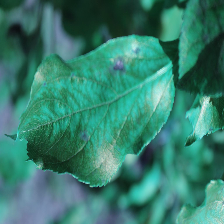

In [12]:
data[0]

In [13]:
target[0]

3

<function matplotlib.pyplot.show(close=None, block=None)>

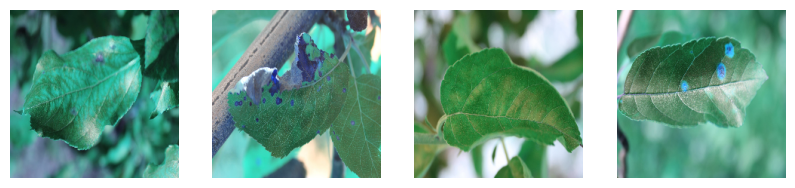

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10,10))
for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(data[i],cmap='gray')
  plt.axis('off')

plt.show

**preprocessing and normalization without augmentation**

In [15]:
import numpy as np

data=np.array(data)/255.0

In [16]:
data = np.array(data)
targets = np.array(target)

In [17]:
data.shape

(1821, 224, 224, 3)

In [18]:
data.ndim

4

In [19]:
data= np.reshape(data,(data.shape[0],img_size,img_size,3))

In [20]:
data.shape

(1821, 224, 224, 3)

In [21]:
data.ndim

4

In [22]:
target= np.array(target)  # converting in to numpy for computational purpose

**One hot encoding to set the target variable without aug**

In [23]:
from tensorflow.keras.utils import to_categorical
new_target = to_categorical(targets)

**Splitting the data**

In [24]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(data,new_target,test_size=0.2,random_state=42,stratify=targets)

In [25]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1456, 224, 224, 3), (365, 224, 224, 3), (1456, 4), (365, 4))

**CNN model Without Augmentation**

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation

model = Sequential()

# -------------------- First Convolution Block --------------------
model.add(Conv2D(32, (3,3), input_shape = data.shape[1:], padding='same'))           #without augment
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# -------------------- Second Convolution Block --------------------
model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# -------------------- Third Convolution Block --------------------
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# -------------------- Flatten Layer --------------------
model.add(Flatten())

# -------------------- Fully Connected Layer --------------------
model.add(Dense(128, activation='relu'))

# -------------------- Dropout Layer --------------------
model.add(Dropout(0.2))

# -------------------- Output Layer --------------------
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile**

In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Summary**

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,844 (49.36 MB)

 Trainable params: 12,939,396 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 22s 248ms/step - accuracy: 0.3365 - loss: 18.5359 - val_accuracy: 0.3425 - val_loss: 1.3800
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.3434 - loss: 1.3745 - val_accuracy: 0.3425 - val_loss: 1.3699
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.3413 - loss: 1.3452 - val_accuracy: 0.3425 - val_loss: 1.3574
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.3565 - loss: 1.3349 - val_accuracy: 0.3260 - val_loss: 1.3471
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.3805 - loss: 1.3013 - val_accuracy: 0.3260 - val_loss: 1.3379
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.4190 - loss: 1.2623 - val_accuracy: 0.3260 - val_loss: 1.3302
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.4128 - loss: 1.2635 - val_accuracy: 0.3260 - val_loss: 1.3231
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.4251 - loss: 1.2371 - val_accuracy: 0.3260 

In [30]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4301 - loss: 1.1967


In [31]:
y_predicted= model.predict(x_test)
y_predicted


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


array([[0.2020182 , 0.12983704, 0.278599  , 0.38954577],
       [0.465149  , 0.00409483, 0.51368994, 0.01706621],
       [0.2020182 , 0.12983704, 0.278599  , 0.38954577],
       ...,
       [0.2020182 , 0.12983704, 0.278599  , 0.38954577],
       [0.34971663, 0.04690498, 0.44470346, 0.15867493],
       [0.3927559 , 0.0273193 , 0.48273894, 0.09718582]], dtype=float32)

In [32]:
y_predicted[0]

array([0.2020182 , 0.12983704, 0.278599  , 0.38954577], dtype=float32)

In [33]:
y_predicted=np.argmax(y_predicted,axis=1)  # axis=1 refers to columns
y_predicted

array([3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2,
       3, 2, 3, 3, 3, 2, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3,
       3, 2, 3, 2, 3, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 0, 2, 2, 2, 3, 3, 3,
       3, 3, 3, 2, 3, 3, 0, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3, 2, 2, 3, 3, 3,
       3, 3, 3, 2, 2, 2, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3,
       3, 2, 2, 2, 2, 3, 2, 2, 3, 2, 3, 3, 2, 2, 2, 3, 3, 3, 3, 3, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 0, 3, 0, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 3, 2, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3,
       2, 3, 2, 3, 3, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 2, 2, 2, 3, 3,
       2, 2, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       2, 3, 3, 2, 2, 2, 3, 3, 2, 3, 2, 3, 2, 3, 3, 0, 2, 2, 0, 3, 2, 2,
       2, 2, 3, 2, 2, 2, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 2,
       2, 2, 3, 3, 3, 2, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 0, 3, 2, 2, 2,
       2, 3, 3, 3, 2, 3, 3, 0, 3, 3, 0, 2, 2, 2, 3,

In [34]:
y_test   # actual output
y_actual=np.argmax(y_test,axis=1)
y_actual

array([2, 0, 2, 2, 2, 3, 0, 3, 0, 2, 0, 3, 1, 2, 2, 3, 0, 2, 0, 2, 3, 2,
       2, 2, 2, 0, 3, 0, 0, 2, 0, 2, 2, 2, 3, 0, 3, 3, 2, 3, 0, 3, 3, 2,
       3, 2, 3, 0, 2, 0, 0, 2, 0, 1, 0, 3, 2, 0, 3, 0, 0, 2, 2, 3, 3, 0,
       3, 2, 2, 3, 3, 3, 0, 3, 0, 3, 2, 3, 2, 3, 3, 0, 2, 2, 3, 2, 3, 3,
       3, 2, 0, 0, 0, 0, 3, 3, 2, 0, 1, 2, 3, 3, 0, 1, 2, 2, 2, 3, 1, 1,
       2, 0, 0, 0, 2, 0, 0, 1, 2, 2, 3, 3, 0, 0, 0, 2, 3, 2, 2, 3, 2, 0,
       0, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 2, 0, 3, 0, 0, 0, 3, 2, 2, 0, 2,
       0, 3, 2, 3, 2, 0, 3, 3, 3, 3, 3, 2, 3, 2, 3, 2, 3, 0, 1, 3, 3, 0,
       3, 3, 0, 3, 2, 2, 3, 3, 2, 3, 3, 3, 0, 3, 2, 2, 3, 2, 0, 2, 3, 3,
       0, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 0, 2, 2, 0, 0, 1, 3, 3, 2, 1, 0,
       0, 0, 0, 2, 0, 2, 2, 2, 2, 3, 2, 2, 3, 2, 0, 0, 0, 3, 0, 3, 2, 3,
       2, 0, 2, 0, 0, 0, 0, 2, 3, 0, 3, 2, 3, 2, 1, 3, 3, 3, 1, 3, 0, 2,
       0, 3, 3, 3, 0, 2, 2, 0, 0, 2, 1, 3, 0, 0, 2, 3, 3, 2, 0, 0, 2, 2,
       0, 3, 3, 3, 2, 2, 3, 0, 2, 3, 2, 3, 0, 3, 0,

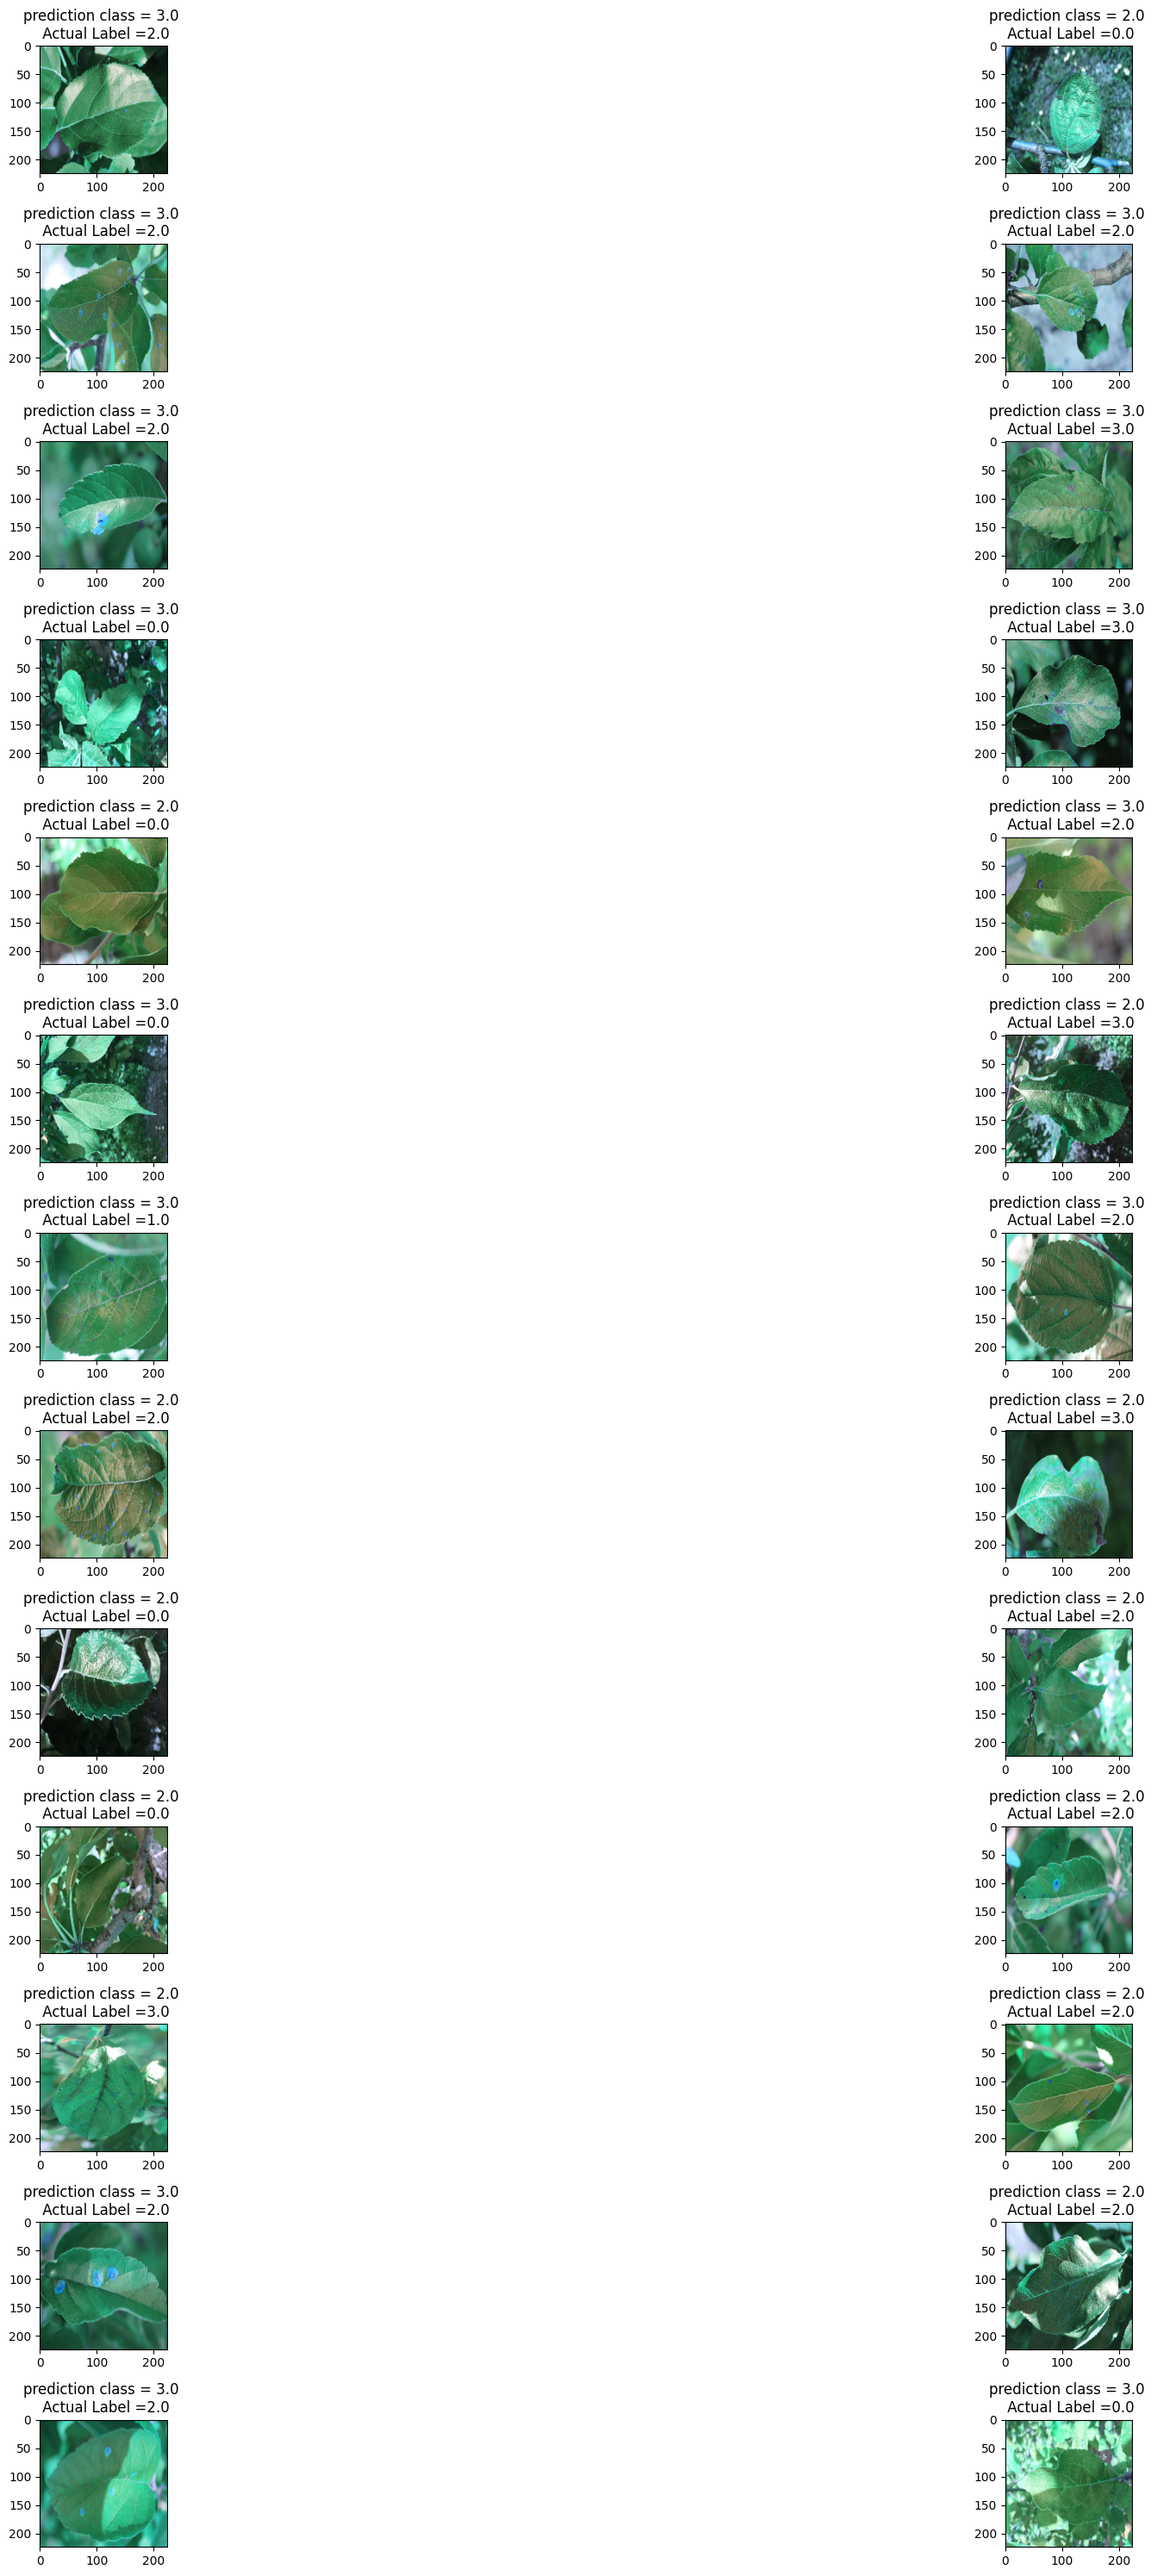

In [35]:
from matplotlib import axes
import matplotlib.pyplot as plt
l=13
w=2
fig, axes= plt.subplots(l,w,figsize=(30,30))
axes=axes.ravel()
for i in np.arange(0,l*w):
  axes[i].imshow(x_test[i])
  axes[i].set_title(f"prediction class = {y_predicted[i]:0.1f} \n Actual Label ={y_actual[i]:0.1f}")
plt.subplots_adjust(wspace=0.5)
plt.tight_layout()

**Evaluvation metrices with Augmentation**

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict probabilities
y_pred = model.predict(x_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Evaluation metrics
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Accuracy : 0.4301
Precision: 0.4894
Recall   : 0.4301
F1 Score : 0.3708


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


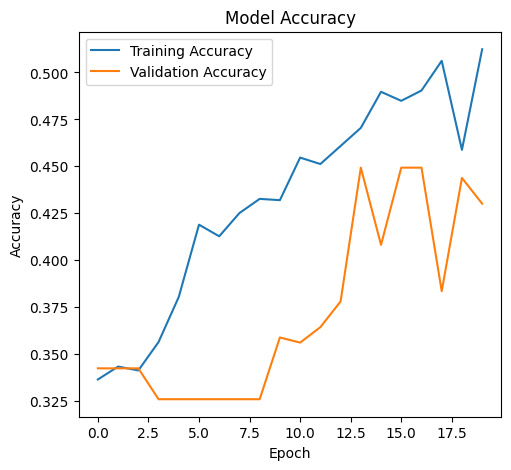

In [37]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

**CNN With Augmenation**

---



In [2]:
import cv2
import os
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
project_path = "/content/drive/MyDrive/CNN_project/plant_pathology"

In [5]:
os.listdir(project_path)

['train.csv', 'train_images', '.ipynb_checkpoints']

In [6]:
train_df = pd.read_csv(project_path + "/train.csv")
train_df

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0
...,...,...,...,...,...
1816,Train_1816,0,0,0,1
1817,Train_1817,1,0,0,0
1818,Train_1818,1,0,0,0
1819,Train_1819,0,0,1,0


In [7]:
train_df["label"] = train_df.iloc[:, 1:].idxmax(axis=1)

In [8]:
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab,label
0,Train_0,0,0,0,1,scab
1,Train_1,0,1,0,0,multiple_diseases
2,Train_2,1,0,0,0,healthy
3,Train_3,0,0,1,0,rust
4,Train_4,1,0,0,0,healthy


In [9]:
train_df["label"].value_counts()

,count
label,
rust,622
scab,592
healthy,516
multiple_diseases,91


In [10]:
img_size = 224

data = []
target = []


label_dict = {
    "healthy": 0,
    "multiple_diseases": 1,
    "rust": 2,
    "scab": 3
}

image_folder = os.path.join(project_path, "train_images")

for index, row in train_df.iterrows():

    if index % 100 == 0:
        print(f"Processing image {index}")

    img_name = row["image_id"] + ".jpg"
    img_path = os.path.join(image_folder, img_name)

    img = cv2.imread(img_path)

    if img is None:
        print("Cannot read:", img_path)
        continue

    try:
        resized = cv2.resize(img, (img_size, img_size))
        data.append(resized)
        target.append(label_dict[row["label"]])

    except Exception as e:
        print("Error at:", img_path)
        print(e)

Processing image 0
Processing image 100
Processing image 200
Processing image 300
Processing image 400
Processing image 500
Processing image 600
Processing image 700
Processing image 800
Processing image 900
Processing image 1000
Processing image 1100
Processing image 1200
Processing image 1300
Processing image 1400
Processing image 1500
Processing image 1600
Processing image 1700
Processing image 1800


In [47]:
# img_size = 100
# # img_size = 224

# data = []
# target = []

# label_dict = {
#     "healthy": 0,
#     "multiple_diseases": 1,
#     "rust": 2,
#     "scab": 3
# }

# image_folder = os.path.join(project_path, "train_images")

# for index, row in train_df.iterrows():

#     img_name = row["image_id"] + ".jpg"
#     img_path = os.path.join(image_folder, img_name)

#     img = cv2.imread(img_path)

#     try:
#         # gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         resized = cv2.resize(img, (img_size, img_size))

#         data.append(resized)
#         target.append(label_dict[row["label"]])

#     except Exception as e:
#         print("Exception:", e)

In [11]:
print("Total Images :", len(data))
print("Total Labels :", len(target))

Total Images : 1821
Total Labels : 1821


<function matplotlib.pyplot.show(close=None, block=None)>

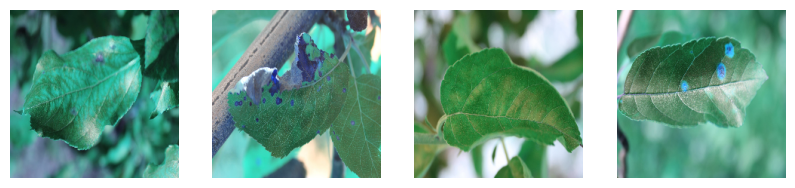

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10,10))
for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(data[i],cmap='gray')
  plt.axis('off')

plt.show

**Image Augmenation**

In [13]:
import cv2
import random
import numpy as np

# ---------------- Rotation ----------------
def rotate_image(image, angle_range=(-15, 15)):
    angle = random.uniform(*angle_range)

    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        image,
        matrix,
        (w, h),
        borderMode=cv2.BORDER_REFLECT
    )

    return rotated


# ---------------- Horizontal Flip ----------------
def flip_horizontal(image):
    return cv2.flip(image, 1)


# ---------------- Zoom ----------------
def zoom_image(image, zoom_range=(0.8, 1.2)):

    zoom = random.uniform(*zoom_range)

    h, w = image.shape[:2]

    new_h = int(h * zoom)
    new_w = int(w * zoom)

    resized = cv2.resize(image, (new_w, new_h))

    if zoom > 1:

        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2

        result = resized[start_h:start_h+h,
                         start_w:start_w+w]

    else:

        # result = np.zeros((h, w), dtype=np.uint8)
        result = np.zeros_like(image)

        start_h = (h-new_h)//2
        start_w = (w-new_w)//2

        result[start_h:start_h+new_h,
               start_w:start_w+new_w] = resized

    return result


# ---------------- Shift ----------------
def shift_image(image, shift_range=(-10, 10)):

    tx = random.randint(*shift_range)
    ty = random.randint(*shift_range)

    h, w = image.shape[:2]

    matrix = np.float32([[1,0,tx],
                         [0,1,ty]])

    shifted = cv2.warpAffine(
        image,
        matrix,
        (w,h),
        borderMode=cv2.BORDER_REFLECT
    )

    return shifted


# ---------------- Brightness ----------------
def adjust_brightness(image,
                      brightness_range=(0.7,1.3)):

    factor = random.uniform(*brightness_range)

    image = image.astype(np.float32)

    image = image * factor

    image = np.clip(image,0,255)

    return image.astype(np.uint8)


# ---------------- List ----------------
augmentation_functions = [

    rotate_image,
    flip_horizontal,
    zoom_image,
    shift_image,
    adjust_brightness

]

augmentation_names = [

    "Rotate",
    "Flip",
    "Zoom",
    "Shift",
    "Brightness"

]

In [14]:
import random

print("Number of samples before augmentation:", len(data))

augmented_data = []
augmented_target = []

# Number of images to augment (10%)
num_to_augment = int(0.20 * len(data))

# Randomly select 10% of image indices
selected_indices = random.sample(range(len(data)), num_to_augment)

for idx in selected_indices:
    image = data[idx]
    label = target[idx]

    for aug_func in augmentation_functions:
      augmented_image = aug_func(image)
      augmented_data.append(augmented_image)
      augmented_target.append(label)

# Combine original and augmented data
combined_data = data + augmented_data
combined_targets = target + augmented_target

print("Original Images :", len(data))
print("Augmented Images:", len(augmented_data))
print("Total Images    :", len(combined_data))

Number of samples before augmentation: 1821
Original Images : 1821
Augmented Images: 1820
Total Images    : 3641


**Normalization and preprocessing with augmentation**

In [15]:
import numpy as np

combined_data=np.array(combined_data)/255.0

In [16]:
combined_data = np.array(combined_data, dtype=np.float32)
combined_targets = np.array(combined_targets)

In [17]:
combined_data.shape

(3641, 224, 224, 3)

In [18]:
combined_data.ndim

4

In [19]:
combined_data= np.reshape(combined_data,(combined_data.shape[0],img_size,img_size,3))

In [20]:
combined_data.shape

(3641, 224, 224, 3)

In [21]:
combined_data.ndim

4

**One hot encoding to set the target variable with aug**

In [22]:
from tensorflow.keras.utils import to_categorical
new_target = to_categorical(combined_targets)

In [23]:
new_target

array([[0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.]])

In [24]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(combined_data,new_target,test_size=0.2,random_state=42,stratify=combined_targets)

In [25]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((2912, 224, 224, 3), (729, 224, 224, 3), (2912, 4), (729, 4))

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation

model = Sequential()

# -------------------- First Convolution Block --------------------
model.add(Conv2D(32, (3,3), input_shape = combined_data.shape[1:], padding='same'))  # with augment
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# -------------------- Second Convolution Block --------------------
model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# -------------------- Third Convolution Block --------------------
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# -------------------- Flatten Layer --------------------
model.add(Flatten())

# -------------------- Fully Connected Layer --------------------
model.add(Dense(128, activation='relu'))

# -------------------- Dropout Layer --------------------
model.add(Dropout(0.2))

# -------------------- Output Layer --------------------
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,844 (49.36 MB)

 Trainable params: 12,939,396 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - accuracy: 0.3266 - loss: 8.0956 - val_accuracy: 0.3169 - val_loss: 1.3721
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.3733 - loss: 1.3227 - val_accuracy: 0.3169 - val_loss: 1.3517
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.4121 - loss: 1.2476 - val_accuracy: 0.3210 - val_loss: 1.3341
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.4131 - loss: 1.2257 - val_accuracy: 0.3182 - val_loss: 1.3293
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.4207 - loss: 1.2021 - val_accuracy: 0.3182 - val_loss: 1.3213
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.4406 - loss: 1.1936 - val_accuracy: 0.4170 - val_loss: 1.2449
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.4413 - loss: 1.1634 - val_accuracy: 0.4458 - val_loss: 1.1473
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.4505 - loss: 1.1625 - val_accuracy: 0.4678

In [30]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5377 - loss: 1.0735


In [31]:
y_predicted= model.predict(x_test)
y_predicted


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


array([[1.70606628e-01, 1.09704904e-01, 2.67088890e-01, 4.52599525e-01],
       [5.69202960e-01, 1.22090960e-05, 4.20472324e-01, 1.03124501e-02],
       [1.70606628e-01, 1.09704904e-01, 2.67088890e-01, 4.52599525e-01],
       ...,
       [6.67001605e-01, 6.37458584e-08, 3.32117468e-01, 8.80845590e-04],
       [3.96598577e-01, 3.98955401e-03, 4.58613724e-01, 1.40798151e-01],
       [3.95400852e-01, 4.09271289e-03, 4.58181202e-01, 1.42325237e-01]],
      dtype=float32)

In [32]:
y_predicted[0]


array([0.17060663, 0.1097049 , 0.2670889 , 0.45259953], dtype=float32)

In [33]:
y_predicted=np.argmax(y_predicted,axis=1)  # axis=1 refers to columns
y_predicted

array([3, 0, 3, 0, 3, 2, 0, 2, 3, 3, 2, 0, 3, 2, 3, 0, 0, 3, 3, 3, 0, 3,
       2, 3, 3, 2, 0, 2, 2, 2, 3, 3, 3, 2, 3, 2, 0, 3, 0, 2, 3, 0, 2, 2,
       2, 3, 0, 0, 3, 3, 3, 0, 0, 3, 2, 2, 0, 3, 3, 3, 3, 0, 2, 2, 0, 3,
       0, 0, 3, 3, 3, 0, 2, 3, 3, 0, 3, 3, 3, 2, 0, 2, 0, 3, 2, 3, 3, 3,
       0, 0, 0, 3, 2, 3, 0, 2, 2, 3, 3, 3, 3, 0, 3, 2, 0, 2, 3, 2, 3, 3,
       2, 3, 0, 3, 3, 2, 3, 0, 0, 0, 3, 3, 3, 3, 0, 3, 2, 3, 0, 3, 3, 3,
       3, 2, 3, 0, 2, 3, 3, 3, 0, 3, 0, 3, 3, 3, 0, 0, 3, 0, 3, 2, 3, 0,
       2, 0, 3, 0, 3, 0, 3, 0, 2, 0, 0, 2, 3, 0, 2, 2, 2, 3, 2, 0, 0, 2,
       2, 2, 3, 2, 3, 0, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 0, 3, 2, 3, 2, 0,
       3, 3, 3, 0, 0, 3, 3, 2, 0, 3, 3, 3, 0, 3, 2, 2, 2, 3, 3, 3, 3, 2,
       2, 3, 0, 3, 3, 3, 0, 3, 3, 3, 3, 2, 3, 3, 3, 3, 2, 3, 2, 2, 2, 3,
       0, 2, 3, 3, 3, 2, 3, 3, 3, 2, 2, 3, 2, 3, 3, 3, 0, 3, 3, 3, 3, 3,
       2, 3, 3, 2, 2, 3, 2, 2, 0, 3, 0, 3, 0, 3, 2, 0, 2, 3, 0, 3, 3, 0,
       2, 2, 3, 3, 2, 3, 0, 3, 3, 0, 3, 0, 0, 0, 3,

In [34]:
y_test   # actual output
y_actual=np.argmax(y_test,axis=1)
y_actual

array([1, 2, 3, 0, 3, 2, 2, 2, 1, 3, 2, 0, 3, 0, 3, 0, 0, 3, 3, 2, 2, 2,
       0, 3, 2, 2, 2, 2, 0, 2, 3, 3, 0, 0, 3, 2, 0, 3, 0, 3, 0, 2, 0, 3,
       0, 3, 3, 0, 3, 2, 2, 2, 0, 3, 3, 2, 2, 2, 2, 2, 3, 0, 3, 2, 2, 3,
       0, 2, 3, 3, 3, 0, 2, 2, 3, 0, 2, 2, 3, 2, 0, 2, 0, 3, 0, 3, 2, 3,
       2, 2, 0, 3, 2, 3, 0, 0, 2, 3, 2, 3, 2, 2, 3, 2, 0, 2, 3, 2, 3, 1,
       0, 2, 0, 3, 3, 0, 3, 0, 2, 2, 1, 3, 2, 3, 2, 3, 0, 3, 0, 2, 2, 3,
       3, 0, 2, 0, 3, 1, 3, 0, 0, 1, 0, 3, 2, 3, 0, 0, 2, 0, 3, 0, 2, 0,
       2, 0, 3, 2, 3, 0, 3, 0, 0, 0, 2, 3, 3, 1, 2, 0, 3, 0, 1, 0, 0, 2,
       2, 2, 3, 0, 2, 0, 0, 2, 2, 3, 3, 2, 0, 0, 3, 2, 0, 2, 1, 3, 2, 0,
       3, 3, 3, 0, 2, 3, 3, 2, 2, 1, 3, 0, 2, 2, 2, 2, 3, 3, 3, 3, 2, 2,
       0, 2, 2, 0, 0, 2, 3, 1, 2, 3, 2, 1, 3, 3, 1, 3, 2, 0, 2, 0, 3, 0,
       3, 2, 2, 3, 3, 2, 3, 2, 2, 0, 0, 3, 0, 0, 2, 3, 2, 0, 3, 2, 3, 3,
       0, 2, 0, 3, 0, 3, 0, 2, 0, 3, 0, 3, 0, 1, 2, 2, 0, 3, 2, 3, 0, 0,
       2, 2, 2, 2, 2, 2, 0, 1, 3, 2, 2, 0, 0, 0, 3,

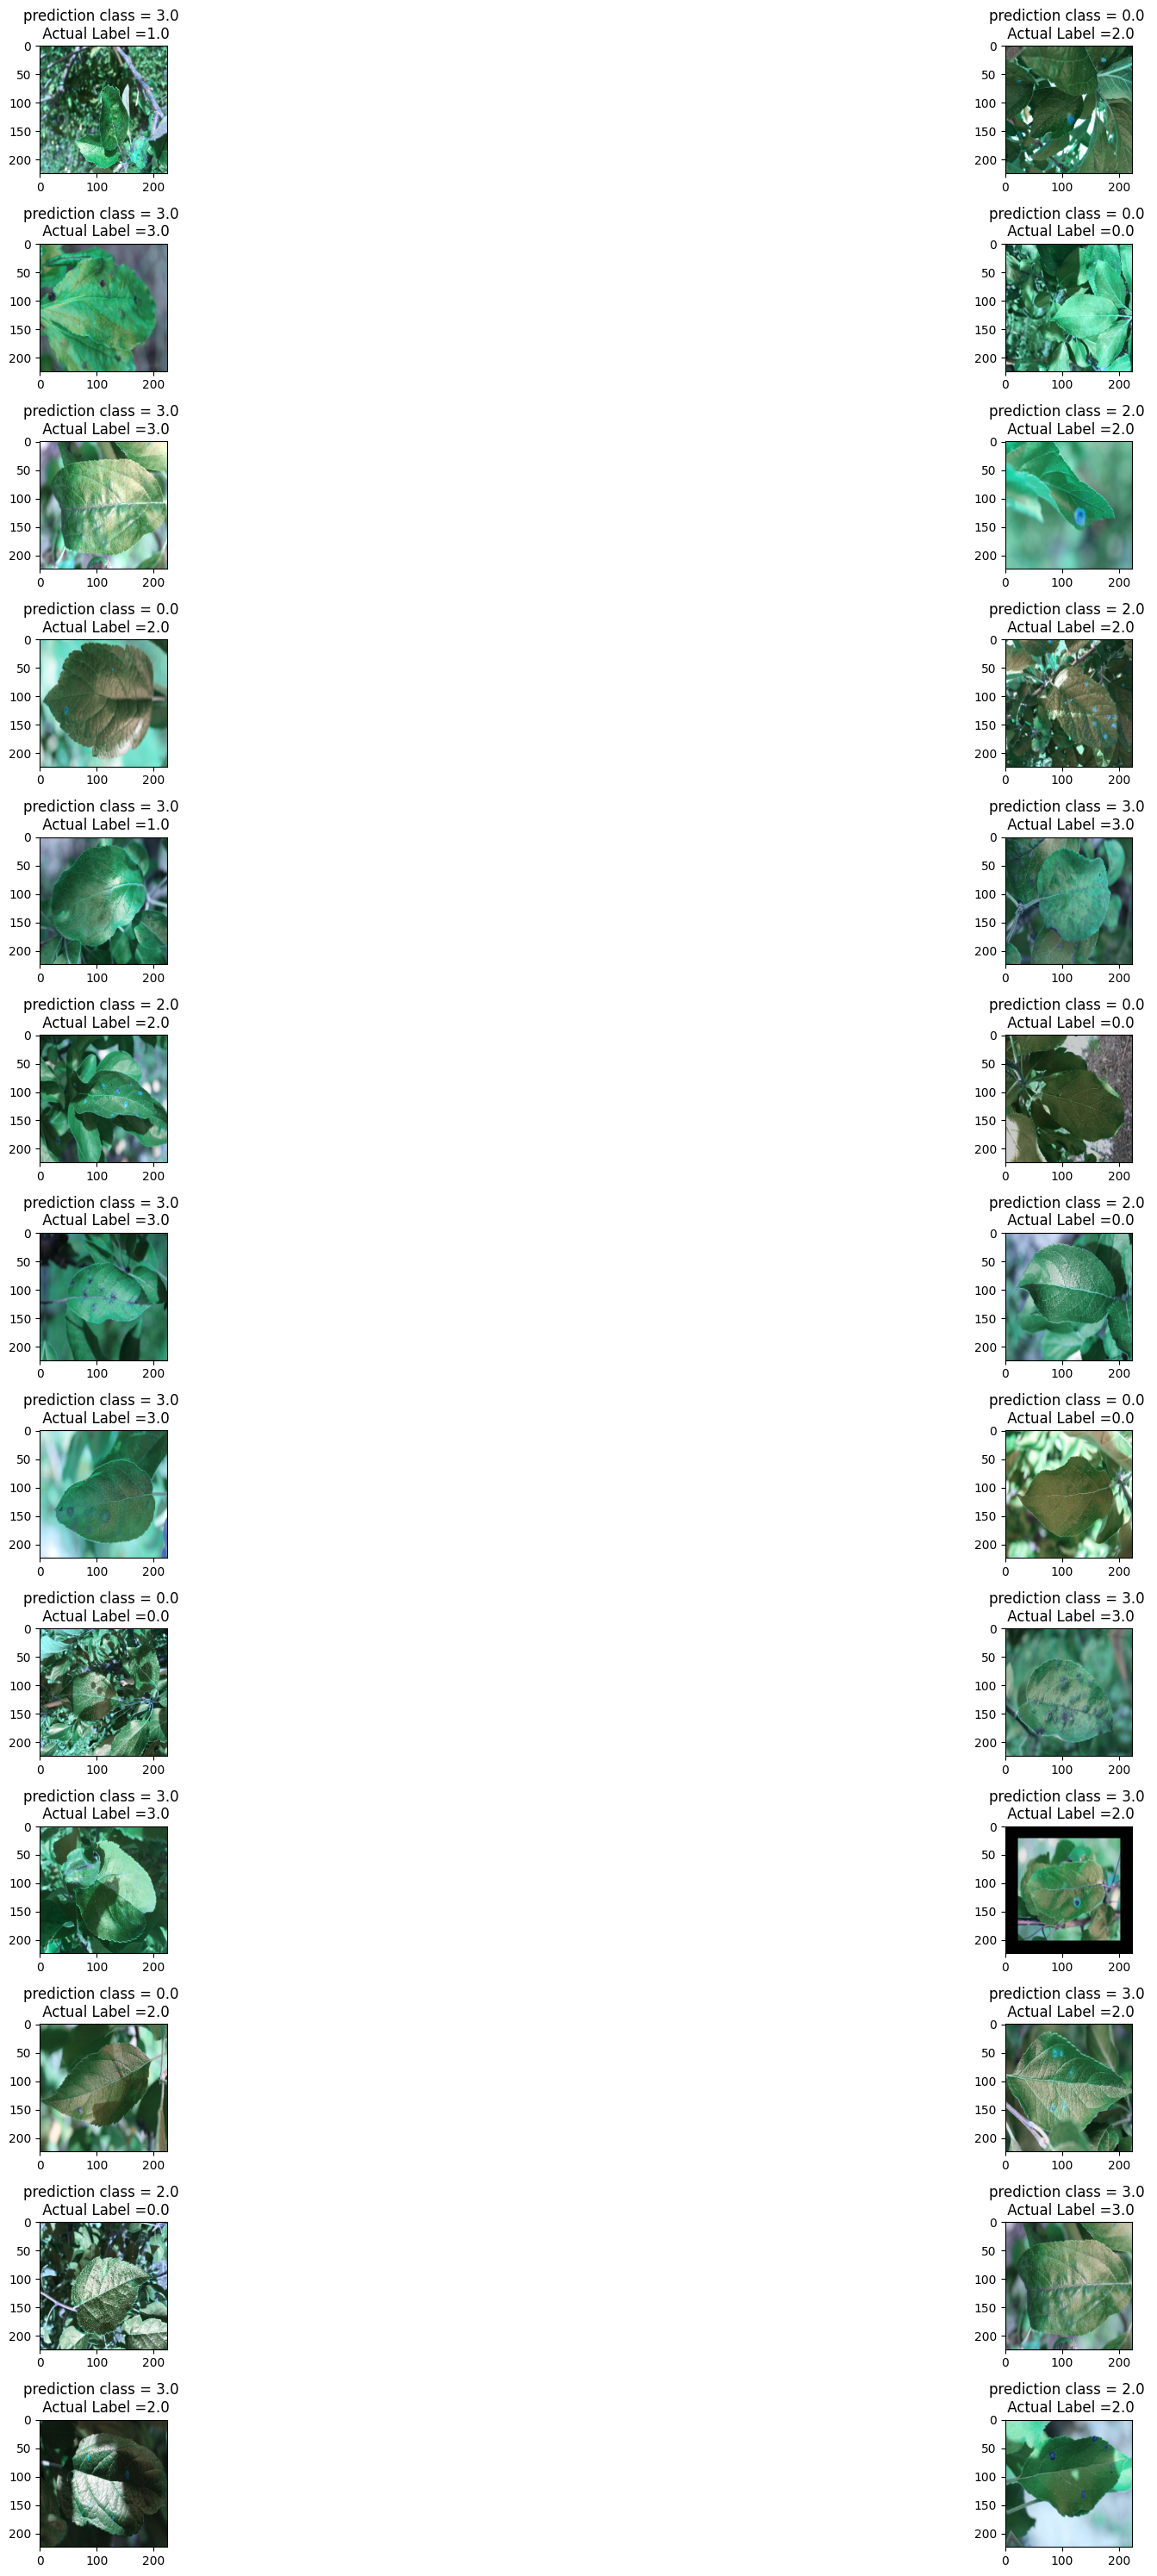

In [35]:
from matplotlib import axes
import matplotlib.pyplot as plt
l=13
w=2
fig, axes= plt.subplots(l,w,figsize=(30,30))
axes=axes.ravel()
for i in np.arange(0,l*w):
  axes[i].imshow(x_test[i])
  axes[i].set_title(f"prediction class = {y_predicted[i]:0.1f} \n Actual Label ={y_actual[i]:0.1f}")
plt.subplots_adjust(wspace=0.5)
plt.tight_layout()

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict probabilities
y_pred = model.predict(x_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Evaluation metrics
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Accuracy : 0.5377
Precision: 0.5100
Recall   : 0.5377
F1 Score : 0.5127


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


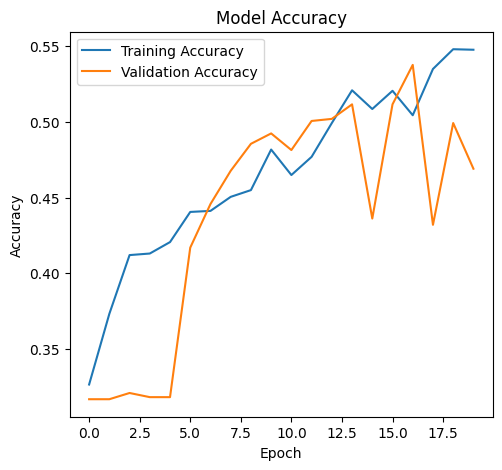

In [37]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

**Transfer learning Model**

---




In [1]:
import cv2
import os
import pandas as pd

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
project_path = "/content/drive/MyDrive/CNN_project/plant_pathology"

In [7]:
os.listdir(project_path)

['train.csv', 'train_images', '.ipynb_checkpoints']

In [8]:
train_df = pd.read_csv(project_path + "/train.csv")
train_df

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0
...,...,...,...,...,...
1816,Train_1816,0,0,0,1
1817,Train_1817,1,0,0,0
1818,Train_1818,1,0,0,0
1819,Train_1819,0,0,1,0


In [9]:
train_df["label"] = train_df.iloc[:, 1:].idxmax(axis=1)

In [10]:
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab,label
0,Train_0,0,0,0,1,scab
1,Train_1,0,1,0,0,multiple_diseases
2,Train_2,1,0,0,0,healthy
3,Train_3,0,0,1,0,rust
4,Train_4,1,0,0,0,healthy


In [11]:
train_df["label"].value_counts()

,count
label,
rust,622
scab,592
healthy,516
multiple_diseases,91


In [12]:
img_size = 224

data = []
target = []


label_dict = {
    "healthy": 0,
    "multiple_diseases": 1,
    "rust": 2,
    "scab": 3
}

image_folder = os.path.join(project_path, "train_images")

for index, row in train_df.iterrows():

    if index % 100 == 0:
        print(f"Processing image {index}")

    img_name = row["image_id"] + ".jpg"
    img_path = os.path.join(image_folder, img_name)

    img = cv2.imread(img_path)

    if img is None:
        print("Cannot read:", img_path)
        continue

    try:
        resized = cv2.resize(img, (img_size, img_size))
        data.append(resized)
        target.append(label_dict[row["label"]])

    except Exception as e:
        print("Error at:", img_path)
        print(e)

Processing image 0
Processing image 100
Processing image 200
Processing image 300
Processing image 400
Processing image 500
Processing image 600
Processing image 700
Processing image 800
Processing image 900
Processing image 1000
Processing image 1100
Processing image 1200
Processing image 1300
Processing image 1400
Processing image 1500
Processing image 1600
Processing image 1700
Processing image 1800


In [ ]:
# # img_size = 100
# img_size = 224

# data = []
# target = []

# label_dict = {
#     "healthy": 0,
#     "multiple_diseases": 1,
#     "rust": 2,
#     "scab": 3
# }

# image_folder = os.path.join(project_path, "train_images")

# for index, row in train_df.iterrows():

#     img_name = row["image_id"] + ".jpg"
#     img_path = os.path.join(image_folder, img_name)

#     img = cv2.imread(img_path)

#     try:
#         # gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         resized = cv2.resize(img, (img_size, img_size))

#         data.append(resized)
#         target.append(label_dict[row["label"]])

#     except Exception as e:
#         print("Exception:", e)

In [13]:
print("Total Images :", len(data))
print("Total Labels :", len(target))

Total Images : 1821
Total Labels : 1821


<function matplotlib.pyplot.show(close=None, block=None)>

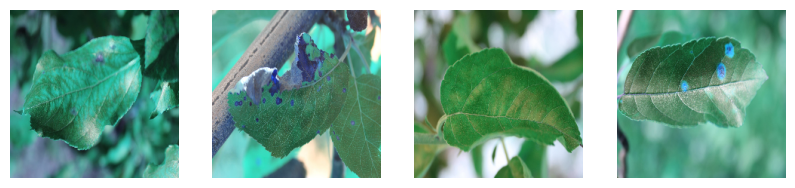

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10,10))
for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(data[i],cmap='gray')
  plt.axis('off')

plt.show

In [15]:
import cv2
import random
import numpy as np

# ---------------- Rotation ----------------
def rotate_image(image, angle_range=(-15, 15)):
    angle = random.uniform(*angle_range)

    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        image,
        matrix,
        (w, h),
        borderMode=cv2.BORDER_REFLECT
    )

    return rotated


# ---------------- Horizontal Flip ----------------
def flip_horizontal(image):
    return cv2.flip(image, 1)


# ---------------- Zoom ----------------
def zoom_image(image, zoom_range=(0.8, 1.2)):

    zoom = random.uniform(*zoom_range)

    h, w = image.shape[:2]

    new_h = int(h * zoom)
    new_w = int(w * zoom)

    resized = cv2.resize(image, (new_w, new_h))

    if zoom > 1:

        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2

        result = resized[start_h:start_h+h,
                         start_w:start_w+w]

    else:

        # result = np.zeros((h, w), dtype=np.uint8)
        result = np.zeros_like(image)

        start_h = (h-new_h)//2
        start_w = (w-new_w)//2

        result[start_h:start_h+new_h,
               start_w:start_w+new_w] = resized

    return result


# ---------------- Shift ----------------
def shift_image(image, shift_range=(-10, 10)):

    tx = random.randint(*shift_range)
    ty = random.randint(*shift_range)

    h, w = image.shape[:2]

    matrix = np.float32([[1,0,tx],
                         [0,1,ty]])

    shifted = cv2.warpAffine(
        image,
        matrix,
        (w,h),
        borderMode=cv2.BORDER_REFLECT
    )

    return shifted


# ---------------- Brightness ----------------
def adjust_brightness(image,
                      brightness_range=(0.7,1.3)):

    factor = random.uniform(*brightness_range)

    image = image.astype(np.float32)

    image = image * factor

    image = np.clip(image,0,255)

    return image.astype(np.uint8)


# ---------------- List ----------------
augmentation_functions = [

    rotate_image,
    flip_horizontal,
    zoom_image,
    shift_image,
    adjust_brightness

]

augmentation_names = [

    "Rotate",
    "Flip",
    "Zoom",
    "Shift",
    "Brightness"

]

In [16]:
import random

print("Number of samples before augmentation:", len(data))

augmented_data = []
augmented_target = []

# Number of images to augment (10%)
num_to_augment = int(0.20 * len(data))

# Randomly select 10% of image indices
selected_indices = random.sample(range(len(data)), num_to_augment)

for idx in selected_indices:
    image = data[idx]
    label = target[idx]

    for aug_func in augmentation_functions:
      augmented_image = aug_func(image)
      augmented_data.append(augmented_image)
      augmented_target.append(label)

# Combine original and augmented data
combined_data = data + augmented_data
combined_targets = target + augmented_target

print("Original Images :", len(data))
print("Augmented Images:", len(augmented_data))
print("Total Images    :", len(combined_data))

Number of samples before augmentation: 1821
Original Images : 1821
Augmented Images: 1820
Total Images    : 3641


**Normalize using EfficientNet preprocessing**

In [17]:
from tensorflow.keras.applications.efficientnet import preprocess_input

combined_data = preprocess_input(np.array(combined_data, dtype=np.float32))

**Efficinet Model**

In [18]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
base_model.trainable = False

**Transfer Learning Model**

In [20]:
# Create transfer learning model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,039 (16.85 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [21]:
from tensorflow.keras.utils import to_categorical
new_target = to_categorical(combined_targets)

In [22]:
new_target

array([[0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

In [23]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(combined_data,new_target,test_size=0.2,random_state=42,stratify=combined_targets)

In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,039 (16.85 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 58s 278ms/step - accuracy: 0.7012 - loss: 0.8511 - val_accuracy: 0.8148 - val_loss: 0.6758
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8118 - loss: 0.5367 - val_accuracy: 0.8436 - val_loss: 0.5143
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8489 - loss: 0.4494 - val_accuracy: 0.8601 - val_loss: 0.4220
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.8678 - loss: 0.3708 - val_accuracy: 0.8779 - val_loss: 0.3661
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8826 - loss: 0.3222 - val_accuracy: 0.8779 - val_loss: 0.3473
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8939 - loss: 0.2946 - val_accuracy: 0.9053 - val_loss: 0.3168
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9045 - loss: 0.2924 - val_accuracy: 0.9081 - val_loss: 0.3188
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9186 - loss: 0.2191 - val_accuracy: 0.9012 -

In [27]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9053 - loss: 0.3168


In [28]:
y_predicted= model.predict(x_test)
y_predicted


23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 351ms/step


array([[7.15361862e-03, 1.33621320e-02, 4.41651821e-01, 5.37832379e-01],
       [2.94912956e-03, 4.10298198e-05, 9.96728659e-01, 2.81267450e-04],
       [1.84993820e-09, 8.96249639e-06, 1.18218955e-08, 9.99991059e-01],
       ...,
       [1.59095097e-02, 3.53639945e-02, 5.51670976e-03, 9.43209767e-01],
       [1.42394390e-04, 5.12327114e-03, 1.04441984e-04, 9.94629860e-01],
       [4.57071304e-01, 5.57308383e-02, 2.61275500e-01, 2.25922346e-01]],
      dtype=float32)

In [29]:
y_predicted[0]

array([0.00715362, 0.01336213, 0.44165182, 0.5378324 ], dtype=float32)

In [30]:
y_predicted=np.argmax(y_predicted,axis=1)  # axis=1 refers to columns
y_predicted

array([3, 2, 3, 0, 3, 2, 2, 2, 2, 3, 2, 0, 3, 0, 3, 0, 0, 2, 3, 2, 2, 2,
       0, 3, 2, 2, 3, 2, 0, 2, 3, 3, 2, 0, 3, 3, 3, 3, 0, 3, 0, 2, 0, 3,
       0, 3, 3, 0, 3, 3, 2, 2, 0, 3, 3, 2, 2, 2, 2, 2, 2, 0, 3, 2, 2, 3,
       0, 2, 3, 3, 3, 1, 2, 2, 3, 0, 2, 2, 3, 2, 1, 2, 0, 3, 0, 3, 2, 3,
       2, 2, 0, 3, 2, 3, 0, 0, 2, 3, 3, 3, 2, 3, 3, 3, 0, 2, 3, 2, 3, 0,
       0, 2, 0, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 0, 3, 0, 2, 2, 0,
       3, 0, 3, 0, 3, 2, 3, 0, 0, 2, 0, 3, 2, 3, 2, 2, 2, 0, 3, 2, 2, 0,
       2, 0, 3, 2, 3, 0, 3, 0, 0, 0, 2, 0, 3, 2, 2, 0, 3, 0, 1, 0, 2, 2,
       2, 2, 3, 2, 2, 0, 0, 2, 2, 3, 3, 2, 3, 0, 3, 0, 0, 2, 2, 2, 2, 0,
       3, 3, 3, 0, 2, 3, 3, 2, 2, 0, 3, 0, 2, 2, 2, 2, 2, 3, 3, 3, 2, 2,
       0, 2, 2, 0, 0, 2, 3, 2, 3, 3, 3, 0, 3, 3, 2, 3, 3, 2, 2, 0, 3, 0,
       3, 2, 2, 3, 3, 2, 3, 2, 3, 0, 0, 0, 0, 0, 3, 3, 2, 0, 2, 2, 2, 3,
       0, 2, 0, 3, 1, 0, 0, 2, 0, 3, 0, 2, 0, 2, 1, 2, 0, 3, 2, 3, 0, 2,
       2, 2, 2, 0, 2, 2, 3, 2, 3, 2, 2, 1, 0, 0, 3,

In [31]:
y_test   # actual output
y_actual=np.argmax(y_test,axis=1)
y_actual

array([1, 2, 3, 0, 3, 2, 2, 2, 2, 3, 2, 0, 3, 0, 3, 0, 0, 2, 3, 2, 2, 2,
       0, 3, 2, 2, 3, 2, 0, 2, 3, 3, 1, 0, 3, 3, 0, 3, 0, 3, 0, 2, 0, 3,
       0, 3, 3, 0, 3, 3, 2, 2, 0, 3, 3, 2, 2, 2, 2, 2, 3, 0, 3, 2, 2, 3,
       0, 2, 3, 3, 3, 1, 2, 2, 3, 0, 2, 2, 3, 2, 1, 2, 0, 3, 0, 3, 2, 3,
       2, 2, 0, 3, 2, 3, 0, 0, 2, 3, 3, 3, 2, 2, 3, 3, 0, 2, 3, 2, 3, 2,
       0, 2, 0, 3, 3, 0, 3, 0, 2, 2, 2, 3, 2, 3, 2, 3, 0, 3, 0, 2, 2, 3,
       3, 0, 3, 0, 3, 2, 3, 0, 0, 2, 0, 3, 2, 3, 0, 1, 2, 0, 3, 0, 2, 0,
       2, 0, 3, 2, 3, 0, 3, 0, 0, 0, 2, 0, 3, 2, 2, 0, 3, 0, 1, 0, 0, 2,
       2, 2, 3, 0, 2, 0, 0, 2, 2, 3, 3, 2, 1, 0, 3, 3, 0, 2, 2, 3, 2, 0,
       3, 3, 3, 0, 2, 3, 3, 2, 2, 2, 3, 0, 2, 2, 2, 2, 2, 3, 3, 3, 2, 2,
       0, 2, 2, 0, 0, 2, 3, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 1, 2, 0, 3, 0,
       3, 2, 2, 3, 3, 2, 3, 2, 3, 0, 0, 3, 0, 0, 3, 3, 2, 0, 2, 2, 3, 3,
       0, 2, 0, 3, 1, 3, 0, 2, 0, 3, 0, 3, 0, 2, 2, 2, 0, 3, 2, 3, 0, 0,
       2, 2, 2, 2, 2, 2, 1, 2, 3, 2, 2, 1, 0, 0, 3,

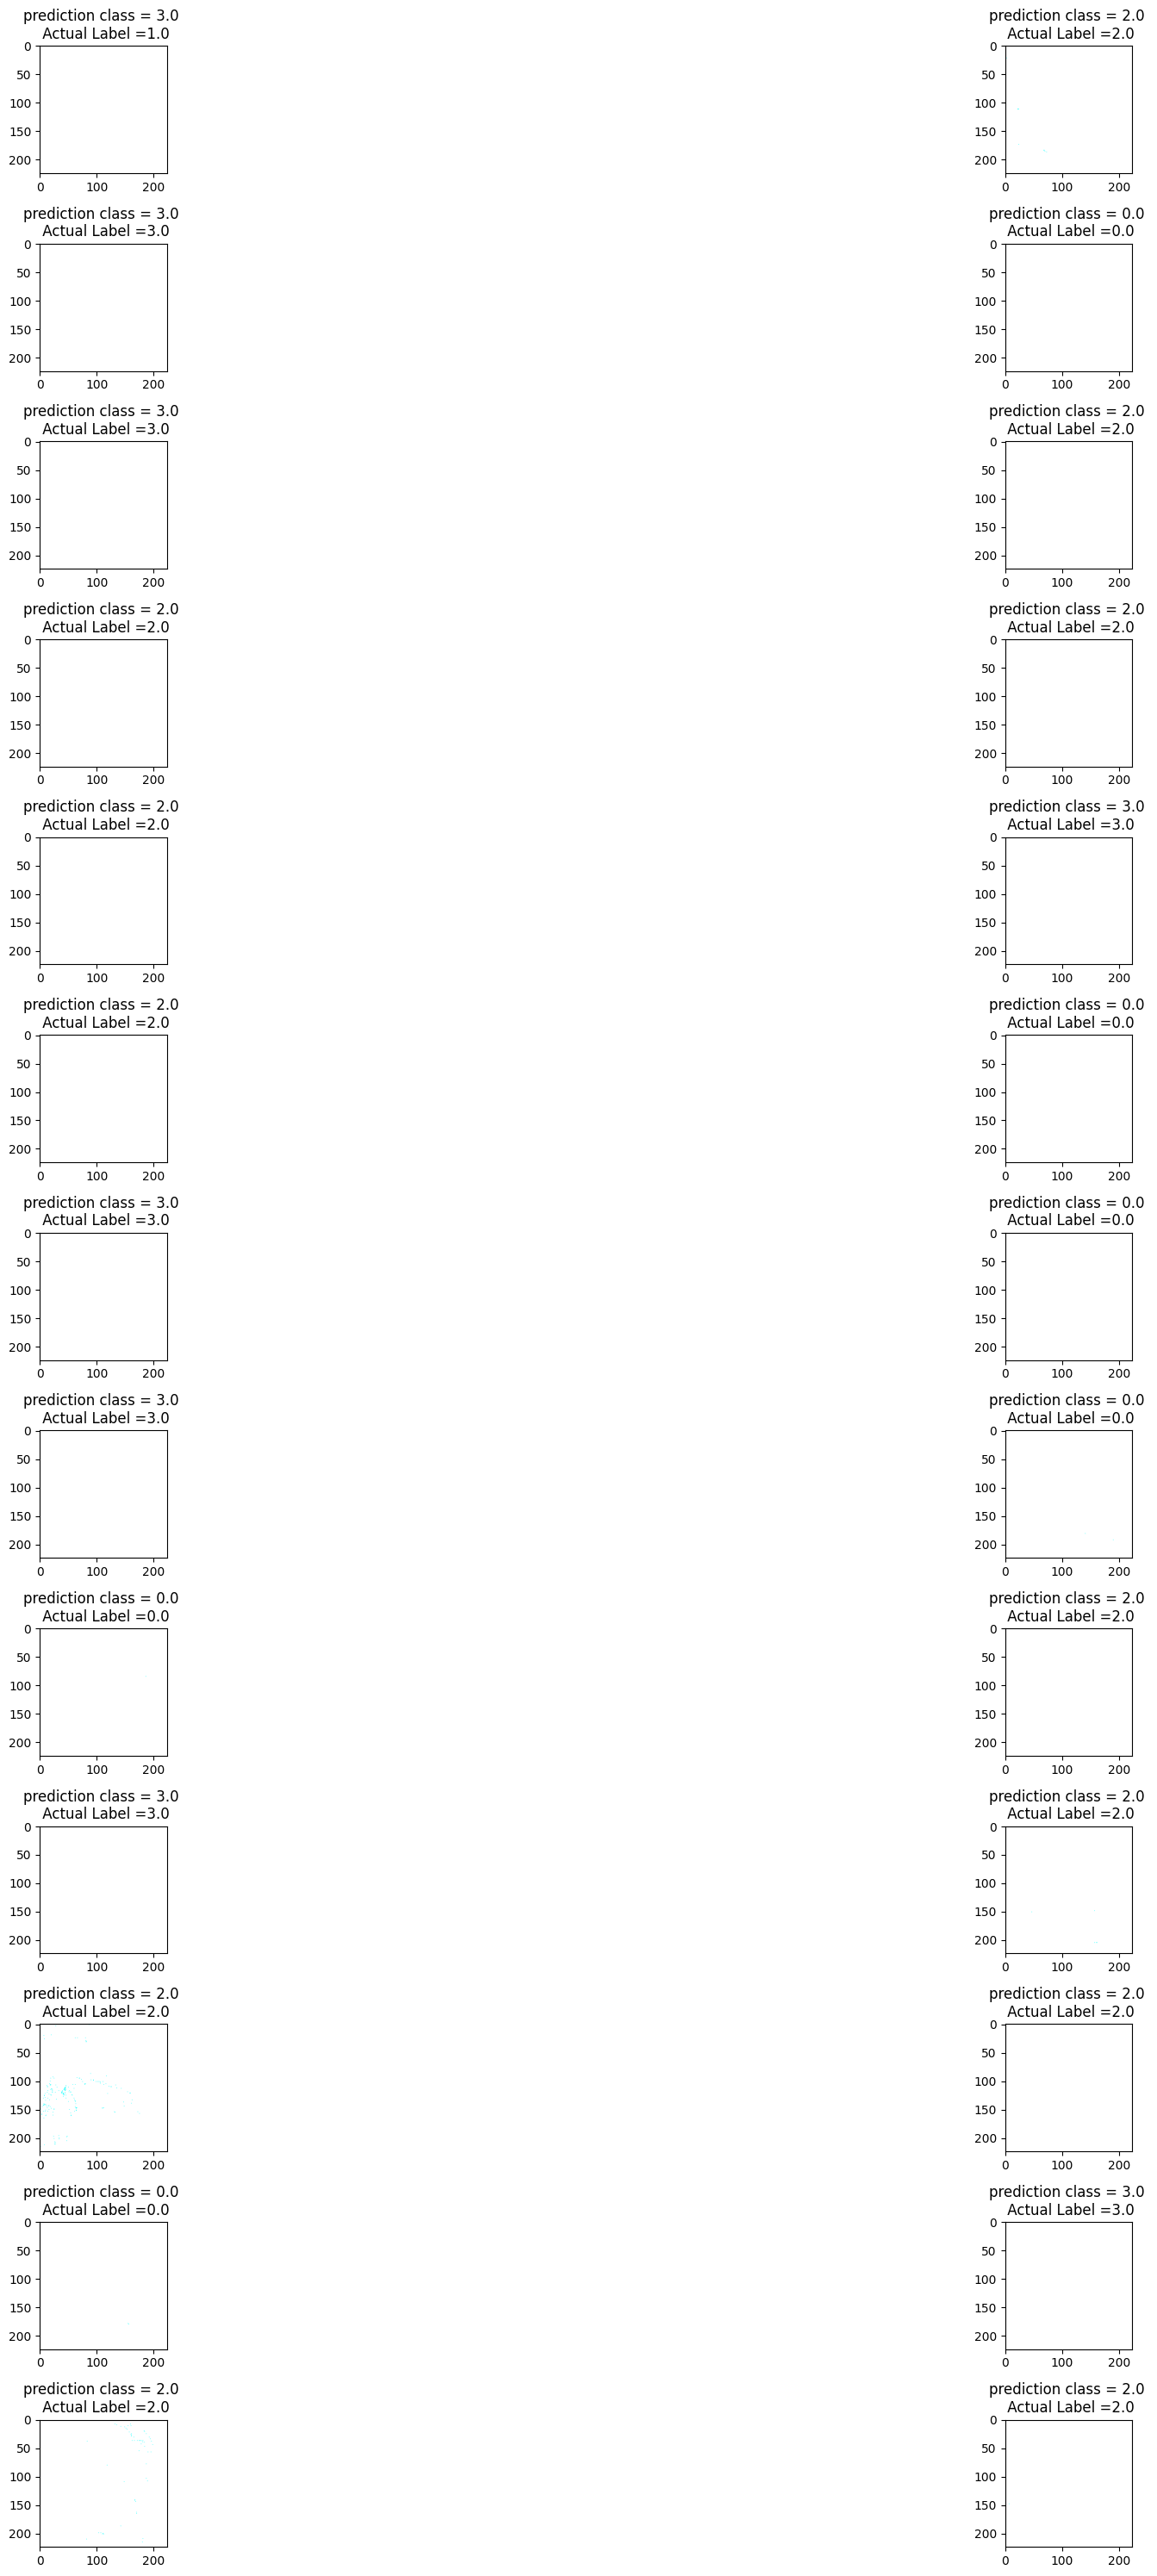

In [35]:
from matplotlib import axes
import matplotlib.pyplot as plt
l=13
w=2
fig, axes= plt.subplots(l,w,figsize=(30,30))
axes=axes.ravel()
for i in np.arange(0,l*w):
  axes[i].imshow(x_test[i])
  axes[i].set_title(f"prediction class = {y_predicted[i]:0.1f} \n Actual Label ={y_actual[i]:0.1f}")
plt.subplots_adjust(wspace=0.5)
plt.tight_layout()

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict probabilities
y_pred = model.predict(x_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Evaluation metrics
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Accuracy : 0.9053
Precision: 0.9073
Recall   : 0.9053
F1 Score : 0.9023


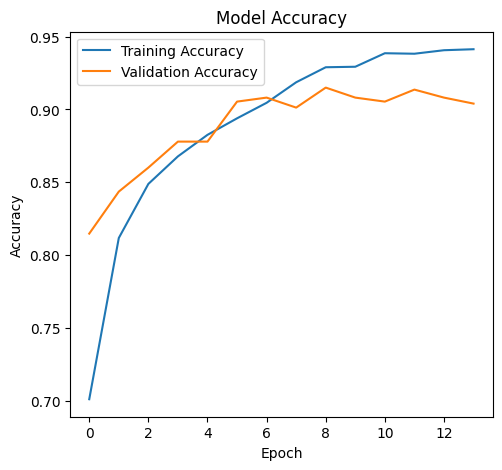

In [34]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()